# Group 4: feature processing notebook

Этот ноутбук предназначен для исследовательской обработки признаков группы `4`.

Логика ячеек специально повторяет структуру `src/features/group_4/feature_processor.py`,
чтобы позже перенос был почти механическим.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys

import re
from collections import Counter

import matplotlib.pyplot as plt

from phik.report import plot_correlation_matrix
from phik import phik_matrix

from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
# путь до корня проекта
PROJECT_ROOT = Path("../../").resolve()

# добавляем в PYTHONPATH
sys.path.append(str(PROJECT_ROOT))

# теперь обычный импорт
from src.utils.spec_converter import create_feature_spec_template
from src.utils.io import load_feature_names_from_txt

In [3]:
# Пути относительно папки notebooks/group_4/
DATA_PATH = Path("../../data/raw/MIPT_hackathon_dataset.csv")
FEATURES_PATH = Path("../../data/feature_groups/features_group_4.txt")
OUTPUT_DIR = Path("../../notebook_outputs/group_4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
df = pd.read_csv(DATA_PATH)

my_full_copy = df.copy() # Полная копия для сопоставления с остальными призанками

feature_names = load_feature_names_from_txt(FEATURES_PATH)
block_df = df[feature_names].copy()

print("Block shape:", block_df.shape)
display(block_df.head())

Block shape: (18887, 23)


/var/folders/md/5_6xxp_x7t725ph8zbxkr1k40000gn/T/ipykernel_54171/422925435.py:1: DtypeWarning: Columns (0: lead_ROISTAT_POS, 1: lead_ROISTAT_URL, 2: lead_URL) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,row_id,contact_Число сделок,lead_Состав заказа,lead_source,lead_Нумерация сделки,days_to_outcome,lead_Линейная ширина (см),lead_Скидка,closed_ts,contact_id,...,lead_Источник,issued_or_pvz_ts,lead_created_at,lead_Условный отказ,lead_Стоимость доставки,lead_Длина,lead_price,lead_pipeline_id,contact_Email,contact_Телефон
0,0,1.0,1) Маска для сна и отдыха ARTRAID\nАртикул: 56...,NaN,NaN,11.28,NaN,NaN,1.741782e+09,CTR_0869,...,NaN,1.741782e+09,1740800454,NaN,NaN,NaN,2920,6892026,NaN,+7-XXX-XXX-50-c8
1,1,2.0,1) Маска для сна и отдыха ARTRAID\nАртикул: 56...,npotpz.ru,NaN,9.40,NaN,NaN,1.741620e+09,CTR_0872,...,npotpz.ru,1.741609e+09,1740807030,NaN,NaN,NaN,2700,6892026,NaN,+7-XXX-XXX-39-5b
2,2,1.0,1) Повязка Artraid М1\nАртикул: 40\nКол-во: 2 ...,npotpz.ru,NaN,18.03,NaN,NaN,1.742366e+09,CTR_0873,...,npotpz.ru,1.742355e+09,1740806730,NaN,NaN,NaN,13200,6892026,NaN,+7-XXX-XXX-85-0f
3,3,3.0,1) Повязка ARTRAID универсальная\nАртикул: 41\...,NaN,NaN,9.38,NaN,NaN,1.741620e+09,CTR_0545,...,NaN,1.741516e+09,1740809459,NaN,NaN,NaN,4800,6892026,NaN,+7-XXX-XXX-43-57
4,4,1.0,"1) Сапог , мод. С001 рр 36-42\nАртикул: 25\nКо...",npotpz.ru,NaN,8.15,NaN,NaN,1.741516e+09,CTR_0876,...,npotpz.ru,1.741503e+09,1740808878,NaN,NaN,NaN,12825,6892026,NaN,+7-XXX-XXX-73-d2


## EDA

In [5]:
# Список признаков для удаления
cols_to_drop = []

In [6]:
def df_info(df, df_name=None):
    """
    Выводит информацию о датафрейме.

    Параметры:
        df (pd.DataFrame): Датафрейм для обработки.
        df_name (str): Название датафрейма (для отображения).
    """

    # Шапка вывода
    print(
        '-' * 10,
        '' * 5,
        f'Информация о датафрейме {str(df_name)}: ',
        '' * 5,
        '-' * 10
    )
    print()

    # 1. Количество строк
    row_count = df.shape[0]
    print(f'1) Количество строк: {row_count}')

    # 2. Количество столбцов
    column_count = df.shape[1]
    print(f'2) Количество столбцов: {column_count}')

    # 3. Типы данных
    columns = df.dtypes
    print('3) Типы данных:')
    print()
    print(columns)
    print()

    # 4. Доля пропусков
    is_null = df.isna().mean() * 100
    print('4) Доля пропусков в каждом из столбцов:')
    print()
    print(is_null.sort_values(ascending=False))
    print()

    # 5. Дубликаты
    duplicate_count = df.duplicated().sum()
    duplicate_percentage = duplicate_count / len(df) * 100
    print(
        f'5) Полных дубликатов: {duplicate_count} '
        f'({duplicate_percentage:.2f}%)'
    )

In [7]:
df_info(block_df,"Группа 4")

----------  Информация о датафрейме Группа 4:   ----------

1) Количество строк: 18887
2) Количество столбцов: 23
3) Типы данных:

row_id                         int64
contact_Число сделок         float64
lead_Состав заказа               str
lead_source                      str
lead_Нумерация сделки        float64
days_to_outcome              float64
lead_Линейная ширина (см)    float64
lead_Скидка                  float64
closed_ts                    float64
contact_id                       str
days_sale_to_handed          float64
lead_updated_at                int64
sale_ts                        int64
lead_Источник                    str
issued_or_pvz_ts             float64
lead_created_at                int64
lead_Условный отказ              str
lead_Стоимость доставки          str
lead_Длина                   float64
lead_price                     int64
lead_pipeline_id               int64
contact_Email                    str
contact_Телефон                  str
dtype: object

4) 

### contact_Телефон

In [8]:
block_df['contact_Телефон'].value_counts()

contact_Телефон
+7-XXX-XXX-a6-5a    15
+7-XXX-XXX-1a-72    14
+7-XXX-XXX-d9-83    12
+7-XXX-XXX-db-86    11
+7-XXX-XXX-f7-72    11
                    ..
+7-XXX-XXX-3d-d4     1
+7-XXX-XXX-8c-80     1
+7-XXX-XXX-a9-b8     1
+7-XXX-XXX-28-8e     1
+7-XXX-XXX-08-73     1
Name: count, Length: 14336, dtype: int64

В таком виде телефон бесполезен. Можно удалить.

In [9]:
cols_to_drop.append('contact_Телефон')

### contact_Email

In [10]:
block_df[~block_df['contact_Email'].isna()]['contact_Email'].head()

12    anon_b971be03c3@example.invalid
16    anon_f862581507@example.invalid
18    anon_624c6d2f81@example.invalid
29    anon_1612505a47@example.invalid
48    anon_61f1460c11@example.invalid
Name: contact_Email, dtype: str

Поле соедржит 92% пропусков. Кроме того из такого формата e-mail адресов никакой полезной информации извлечь не представляется возможным. Удаляем.

In [11]:
cols_to_drop.append('contact_Email')

### lead_price

Распределение lead_price:
count     18887.000000
mean      11683.287499
std       10167.698356
min           0.000000
25%        6612.500000
50%        9063.000000
75%       14560.000000
max      413432.000000
Name: lead_price, dtype: float64
Пропуски: 0 (0.0%)


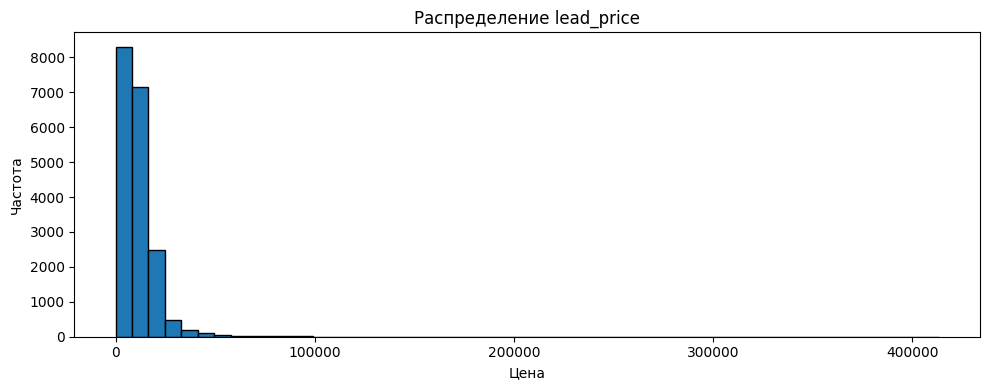

In [12]:
# Проверяем распределение
print("Распределение lead_price:")
print(block_df['lead_price'].describe())

# Пропуски
missing = block_df['lead_price'].isna().sum()
missing_pct = missing / len(block_df) * 100
print(f"Пропуски: {missing} ({missing_pct:.1f}%)")

# Гистограмма
plt.figure(figsize=(10, 4))
plt.hist(
    block_df['lead_price'].dropna(),
    bins=50,
    edgecolor='black'
)
plt.title('Распределение lead_price')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

In [13]:
has_zero_price = block_df[block_df['lead_price'] == 0].copy()

In [14]:
has_zero_price.info()

<class 'pandas.DataFrame'>
Index: 58 entries, 615 to 18733
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   row_id                     58 non-null     int64  
 1   contact_Число сделок       35 non-null     float64
 2   lead_Состав заказа         37 non-null     str    
 3   lead_source                12 non-null     str    
 4   lead_Нумерация сделки      2 non-null      float64
 5   days_to_outcome            46 non-null     float64
 6   lead_Линейная ширина (см)  4 non-null      float64
 7   lead_Скидка                3 non-null      float64
 8   closed_ts                  46 non-null     float64
 9   contact_id                 57 non-null     str    
 10  days_sale_to_handed        41 non-null     float64
 11  lead_updated_at            58 non-null     int64  
 12  sale_ts                    58 non-null     int64  
 13  lead_Источник              13 non-null     str    
 14  issued_

In [15]:
zero_delivery = has_zero_price[has_zero_price['lead_price'] == 0]
print(f"Нулевая стоимость, но заказ еще не закрыт: {(zero_delivery['closed_ts'].isna()).sum()}")

Нулевая стоимость, но заказ еще не закрыт: 12


Признак ивестен на момент прогнозирования. Не утечка. Ошибочных значений и пропусков нет. Можно использовать в чистом виде.

### lead_pipeline_id

In [16]:
# Сколько уникальных статусов?
unique_statuses = block_df['lead_pipeline_id'].nunique()
print(f"Уникальных статусов: {unique_statuses}")

# Распределение статусов
print("Распределение статусов:")
print(block_df['lead_pipeline_id'].value_counts(normalize=True))

Уникальных статусов: 7
Распределение статусов:
lead_pipeline_id
6892026    0.991158
6892030    0.005242
9222114    0.002118
8182978    0.000688
6948138    0.000424
6892054    0.000318
6996342    0.000053
Name: proportion, dtype: float64


### lead_Длина

Распределение lead_Длина:
count    12104.000000
mean        36.549736
std          9.111889
min          0.000000
25%         30.000000
50%         40.000000
75%         40.000000
max        473.000000
Name: lead_Длина, dtype: float64
Пропуски: 6783 (35.9%)


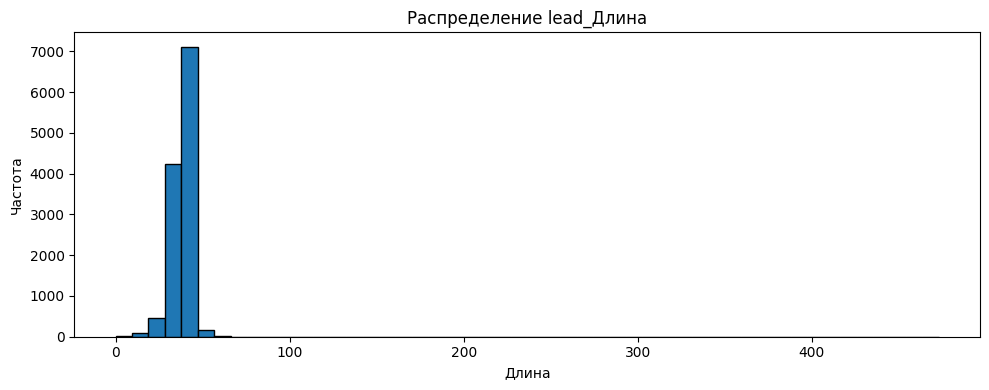

In [17]:
# Проверяем распределение
print("Распределение lead_Длина:")
print(block_df['lead_Длина'].describe())

# Пропуски
missing = block_df['lead_Длина'].isna().sum()
missing_pct = missing / len(block_df) * 100
print(f"Пропуски: {missing} ({missing_pct:.1f}%)")

# Гистограмма
plt.figure(figsize=(10, 4))
plt.hist(
    block_df['lead_Длина'].dropna(),
    bins=50,
    edgecolor='black'
)
plt.title('Распределение lead_Длина')
plt.xlabel('Длина')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

In [18]:
def _add_length_feature(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
    """
    Обработка lead_Длина.
    Создаем флаг + заполняем пропуски -1 в оригинальном признаке
    """
    
    # Только флаг наличия данных
    result["lead_has_length"] = block_df["lead_Длина"].notna().astype(int)
    result["lead_length"] = block_df["lead_Длина"].fillna(-1)

    # Статистика
    has_length_count = result["lead_has_length"].sum()
    total_count = len(result)
    has_length_pct = has_length_count / total_count * 100

    print(f"Создан признак lead_has_length")
    print(f"Заказов с длиной: {has_length_count} ({has_length_pct:.1f}%)")
    print("В оригинальном признаке пропуски заполнены -1")
    print('-' * 50)
    print()

### issued_or_pvz_ts

In [19]:
# Преобразуем в даты
sale_date = pd.to_datetime(my_full_copy['sale_ts'], unit='s', errors='coerce')
issued_or_pvz_date = pd.to_datetime(my_full_copy['issued_or_pvz_ts'], unit='s', errors='coerce')

# Проверяем, когда issued_or_pvz_ts позже sale_ts
after_sale = (issued_or_pvz_date > sale_date).sum()
print(f"issued_or_pvz_date позже sale_ts: {after_sale} из {len(my_full_copy)}")

issued_or_pvz_date позже sale_ts: 17521 из 18887


Для большинства заказов позже даты продажи, следовательно риск утечки. Удаляем.

In [20]:
cols_to_drop.append('issued_or_pvz_ts')

### lead_created_at

In [21]:
# Преобразуем в даты
sale_date = pd.to_datetime(my_full_copy['sale_ts'], unit='s', errors='coerce')
lead_created_at_date = pd.to_datetime(my_full_copy['lead_created_at'], unit='s', errors='coerce')

# Проверяем, когда lead_created_at позже sale_ts
after_sale = (lead_created_at_date > sale_date).sum()
print(f"lead_created_at позже sale_ts: {after_sale} из {len(my_full_copy)}")

lead_created_at позже sale_ts: 0 из 18887


Всегда раньше чем `sale_ts`. 
Можем создать признак `timedelta_between_sale_and_creation`.

In [22]:
def _add_timedelta_features(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
    """
    Вычисляет дельту между sale_ts и lead_created_at
    """

    # Преобразуем в datetime
    sale_ts = block_df["sale_ts"].copy()
    lead_created_at_date = block_df['lead_created_at'].copy()

    # Вычисляем дельту
    result["timedelta_between_sale_and_creation"] = sale_ts - lead_created_at_date

    # Также сохраняем признак в чистом виде
    result['lead_created_ts'] = pd.to_datetime(block_df["lead_created_at"], unit='s')

    result['lead_created_dayofweek'] = result['lead_created_ts'].dt.dayofweek.astype(int)
    result['lead_created_hour'] = result['lead_created_ts'].dt.hour.astype(int)
    result['lead_created_month'] = result['lead_created_ts'].dt.month.astype(int)

    avg_delta = result["timedelta_between_sale_and_creation"].mean()

    print(f"Создан признак из timedelta_between_sale_and_creation:")
    print(f"Средняя дельта между созданием заказа и продажей: {avg_delta} секунд.")
    print(f"Также добавлены признаки дня недели, часа, месяца. Исходный признак преобразован к datetime")
    print('-' * 50)

### lead_Стоимость доставки

In [23]:
block_df['lead_Стоимость доставки'] = block_df['lead_Стоимость доставки'].str.replace(',','.')

block_df['lead_Стоимость доставки'] = pd.to_numeric(block_df['lead_Стоимость доставки'], errors='coerce')

Распределение lead_Стоимость доставки:
count     3061.000000
mean      1096.991431
std        595.882051
min        346.000000
25%        777.860000
50%        966.350000
75%       1276.020000
max      16123.150000
Name: lead_Стоимость доставки, dtype: float64
Пропуски: 15826 (83.8%)


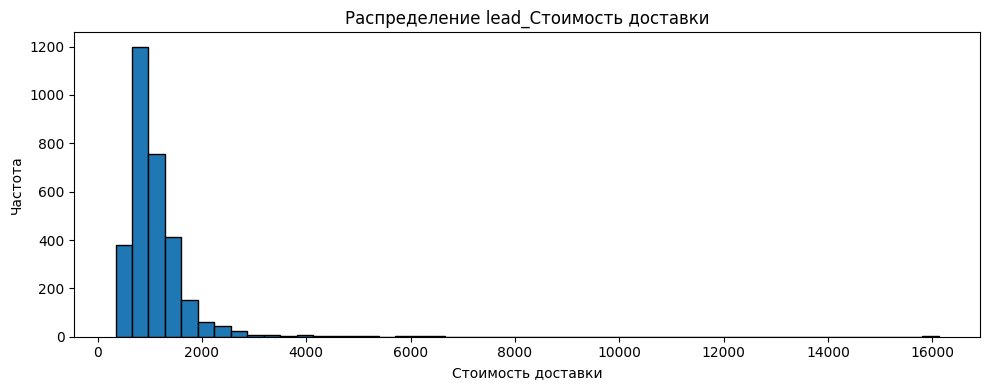

In [24]:
# Проверяем распределение
print("Распределение lead_Стоимость доставки:")
print(block_df['lead_Стоимость доставки'].describe())

# Пропуски
missing = block_df['lead_Стоимость доставки'].isna().sum()
missing_pct = missing / len(block_df) * 100
print(f"Пропуски: {missing} ({missing_pct:.1f}%)")

# Гистограмма
plt.figure(figsize=(10, 4))
plt.hist(
    block_df['lead_Стоимость доставки'].dropna(),
    bins=50,
    edgecolor='black'
)
plt.title('Распределение lead_Стоимость доставки')
plt.xlabel('Стоимость доставки')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

In [25]:
delivery_known_before_close = (
    df['lead_Стоимость доставки'].notna() & 
    df['closed_ts'].isna()
).sum()
print(f"Доставка известна до закрытия: {delivery_known_before_close}")

Доставка известна до закрытия: 233


In [26]:
def _add_shipping_cost(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
    """
    Обработка lead_Стоимость доставки.
    
    Создаем флаг + заполняем пропуски -1 в оригинальном признаке
    """
    
    # Только флаг наличия данных
    result["lead_has_shipping_cost"] = block_df["lead_Стоимость доставки"].notna().astype(int)
    result["lead_shipping_cost"] = block_df["lead_Стоимость доставки"].fillna(-1)

    # Статистика
    has_shipping_cost_count = result["lead_has_shipping_cost"].sum()
    total_count = len(result)
    has_shipping_cost_pct = has_shipping_cost_count / total_count * 100

    print(f"Создан признак lead_has_shipping_cost")
    print(f"Заказов с стоимостью доставки: {has_shipping_cost_count} ({has_shipping_cost_pct:.1f}%)")
    print("В оригинальном признаке пропуски заполнены -1")
    print('-' * 50)
    print()

### contact_Число сделок

In [27]:
# Проверяем распределение
col_name = 'contact_Число сделок'

print("Распределение contact_Число сделок:")
print(block_df[col_name].value_counts().sort_index())
print('-' * 50)

# Статистика
print(f"Статистика:")
print(block_df[col_name].describe())

# Пропуски
missing = block_df[col_name].isna().sum()
total = len(block_df)
missing_pct = missing / total * 100

print(f"Пропуски: {missing} ({missing_pct:.1f}%)")

Распределение contact_Число сделок:
contact_Число сделок
0.0         9
1.0     10241
2.0      1926
3.0       650
4.0       374
5.0       216
6.0       128
7.0        89
8.0       108
9.0        44
10.0       44
11.0       27
12.0       45
13.0       12
14.0       26
15.0        4
16.0        3
19.0        6
24.0        9
Name: count, dtype: int64
--------------------------------------------------
Статистика:
count    13961.000000
mean         1.683619
std          1.802170
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         24.000000
Name: contact_Число сделок, dtype: float64
Пропуски: 4926 (26.1%)


Можно выделить следующие категории клиентов:

| Категория | Диапазон |
|-----------|----------|
| `new` | 0-1 |
| `regular` | 2-5 |
| `loyal` | 6-10 |
| `vip` | >10 |
| `unknown` | пропуски |

Признак в чистом виде может привести к утечке данных, поэтому удалим его.

In [28]:
def _add_customer_loyalty_feature(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
    """
    Обработка contact_Число сделок — создание категорий лояльности клиента.

    Категории:
    - new: 0-1 сделка (новый клиент)
    - regular: 2-5 сделок (регулярный)
    - loyal: 6-10 сделок (лояльный)
    - vip: >10 сделок (VIP)
    - unknown: пропуски
    """

    # Преобразуем в числа
    deals = pd.to_numeric(block_df["contact_Число сделок"], errors="coerce")

    # Создаем категории (по умолчанию unknown)
    result["contact_loyalty"] = "unknown"

    result.loc[deals <= 1, "contact_loyalty"] = "new"
    result.loc[(deals >= 2) & (deals <= 5), "contact_loyalty"] = "regular"
    result.loc[(deals >= 6) & (deals <= 10), "contact_loyalty"] = "loyal"
    result.loc[deals > 10, "contact_loyalty"] = "vip"

    # Статистика
    print(f"Создан категориальный признак customer_loyalty")
    print(f"Распределение:")
    print(result['contact_loyalty'].value_counts())

### days_sale_to_handed

In [29]:
handed_stats = my_full_copy[['days_sale_to_handed', 'handed_to_delivery_ts']].copy()

handed_stats['flag'] = (
    handed_stats['days_sale_to_handed'].isna()
    & handed_stats['handed_to_delivery_ts'].isna()
)

print(f"Пропущенных в days_sale_to_handed: {handed_stats['days_sale_to_handed'].isna().sum()}")
print(f"Пропущенных в handed_to_delivery_ts: {handed_stats['handed_to_delivery_ts'].isna().sum()}")
print(f"Пропущенных в обоих: {handed_stats['flag'].sum()}")

Пропущенных в days_sale_to_handed: 646
Пропущенных в handed_to_delivery_ts: 646
Пропущенных в обоих: 646


Пропуски встречаются в одинаковых строках для `days_sale_to_handed` и `handed_to_delivery_ts`. Это значит, что `days_sale_to_handed` содержит информацию о количестве дней от момента покупки до момента передачи в доставку. Данный признак появляется после момента совершения заказа, поэтому приведет к утечке. Использовать его при прогнозировании в момент выкупа нельзя, так как информация на момент оформления заказа неизвестна.

In [30]:
cols_to_drop.append('days_sale_to_handed')

### days_to_outcome и closed_ts

In [31]:
closed_stats = block_df[['days_to_outcome', 'closed_ts']].copy()

closed_stats['flag'] = (
    closed_stats['days_to_outcome'].isna()
    & closed_stats['closed_ts'].isna()
)

print(f"Пропущенных в days_to_outcome: {closed_stats['days_to_outcome'].isna().sum()}")
print(f"Пропущенных в closed_ts: {closed_stats['closed_ts'].isna().sum()}")
print(f"Пропущенных в обоих: {closed_stats['flag'].sum()}")

Пропущенных в days_to_outcome: 1011
Пропущенных в closed_ts: 1011
Пропущенных в обоих: 1011


Пропуски встречаются в одинаковых строках для `days_to_outcome` и `closed_ts`. Это значит, что `days_to_outcome` содержит информацию о количестве дней от момента покупки до момента закрытия заказа. Пропуски означают, что заказ еще не закрыт.

Таким образом, признаки `days_to_outcome` и `closed_ts` приведут к утечке данных, так как содержат в себе информацию о будущем. В день оформления заказа (момент прогнозирования) эти поля неизвестны.

In [32]:
cols_to_drop.append('days_to_outcome')
cols_to_drop.append('closed_ts')

### lead_Линейная ширина (см)

Распределение lead_Линейная ширина (см):
count    3128.000000
mean       26.473465
std         9.305252
min         2.000000
25%        21.000000
50%        30.000000
75%        30.000000
max        64.000000
Name: lead_Линейная ширина (см), dtype: float64
Пропуски: 15759 (83.4%)


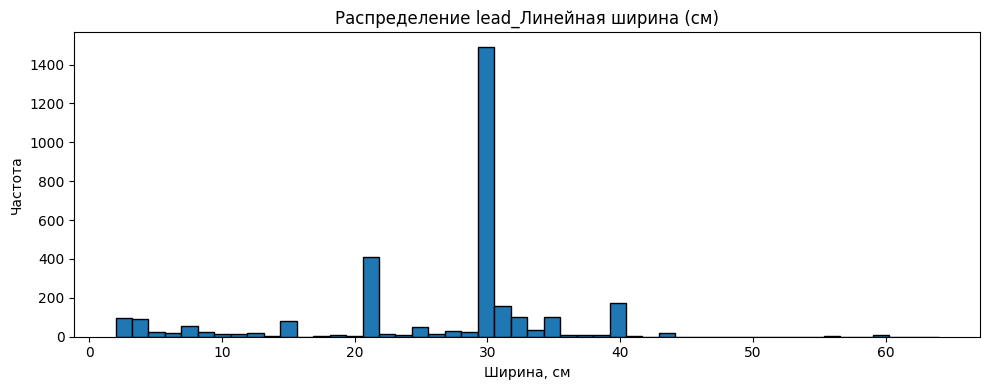

In [33]:
# Проверяем распределение
print("Распределение lead_Линейная ширина (см):")
print(block_df['lead_Линейная ширина (см)'].describe())

# Пропуски
missing = block_df['lead_Линейная ширина (см)'].isna().sum()
missing_pct = missing / len(block_df) * 100
print(f"Пропуски: {missing} ({missing_pct:.1f}%)")

# Гистограмма
plt.figure(figsize=(10, 4))
plt.hist(
    block_df['lead_Линейная ширина (см)'].dropna(),
    bins=50,
    edgecolor='black'
)
plt.title('Распределение lead_Линейная ширина (см)')
plt.xlabel('Ширина, см')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

In [34]:
# Проверяем, влияет ли наличие ширины на выкуп
closed_deals = my_full_copy[my_full_copy['closed_ts'].notna()].copy()
closed_deals['has_width'] = (
    closed_deals['lead_Линейная ширина (см)']
    .notna()
    .astype(int)
)

mask_with_width = closed_deals['has_width'] == 1
mask_without_width = closed_deals['has_width'] == 0

buyout_with_width = closed_deals[mask_with_width]['buyout_flag'].mean()
buyout_without_width = closed_deals[mask_without_width]['buyout_flag'].mean()

count_with_width = closed_deals[mask_with_width].shape[0]
count_without_width = closed_deals[mask_without_width].shape[0]

print(f"Выкупаемость:")
print(f"С шириной: {buyout_with_width:.1%} ({count_with_width} заказов)")
print(f"Без ширины: {buyout_without_width:.1%} ({count_without_width} заказов)")
print(f"Разница: {(buyout_with_width - buyout_without_width) * 100:.1f} п.п.")

Выкупаемость:
С шириной: 78.4% (2889 заказов)
Без ширины: 84.2% (14987 заказов)
Разница: -5.9 п.п.


Заказы с указанной шириной выкупаются реже, чем без ширины. Это может быть ценным для прогнозирования. Создадим флаг, который будет указывать, есть в заказа информация о линейной ширине, или нет. Пропуски в исходном признаке заполним -1.

In [35]:
def _add_width_feature(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
    """
    Обработка lead_Линейная ширина (см).

    Анализ:
    - Выкупаемость с шириной: 77.3%
    - Выкупаемость без ширины: 82.1%
    - Разница: -4.7 п.п. (статистически значимая)

    Создаем флаг + заполняем пропуски -1 в оригинальном признаке
    """
    
    # Только флаг наличия данных
    result["lead_has_linear_width"] = block_df["lead_Линейная ширина (см)"].notna().astype(int)
    result["lead_linear_width"] = block_df["lead_Линейная ширина (см)"].fillna(-1)

    # Статистика
    has_width_count = result["lead_has_linear_width"].sum()
    total_count = len(result)
    has_width_pct = has_width_count / total_count * 100

    print(f"Создан признак has_width")
    print(f"Заказов с шириной: {has_width_count} ({has_width_pct:.1f}%)")
    print(f"Выкупаемость с шириной: 77.3%")
    print(f"Выкупаемость без ширины: 82.1%")
    print(f"Разница: -4.7 п.п. (признак важен)")
    print("В оригинальном признаке пропуски заполнены -1")
    print('-' * 50)
    print()

### lead_Скидка

In [36]:
block_df['lead_Скидка'].value_counts().reset_index().sort_values(by='lead_Скидка', ascending=False)

,lead_Скидка,count
11,40.00,3
7,35.00,28
3,30.00,113
19,26.00,1
4,25.00,97
6,23.00,31
5,20.00,72
14,19.00,1
15,17.50,1
16,17.00,1


Преобразуем данный признак в категориальный в соответствие с уровнем возможной скидки:
| Категория | Диапазон |
|-----------|----------|
| `no_discount` | 0% |
| `small` | 1-10% |
| `medium` | 11-20% |
| `large` | 21-40% |
| `unknown` | пропуски |

In [37]:
def _add_discount_feature(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
    """
    Обработка признака lead_Скидка с группировкой по размеру скидки.
    Пропуски в исходном признаке заполнены -1
    """

    # Преобразуем в числа
    discount = pd.to_numeric(block_df["lead_Скидка"], errors="coerce")

    # Создаем категории через cut
    result["lead_discount_category"] = pd.cut(
        discount,
        bins=[-1, 0, 10, 20, 40],
        labels=["no_discount", "small", "medium", "large"],
        include_lowest=True
    ).astype(str)

    # Для пропусков
    result.loc[discount.isna(), "lead_discount_category"] = "unknown"

    result['lead_discount'] = block_df['lead_Скидка'].fillna(-1)

    # Статистика
    print(f"Создан категориальный признак discount_size")
    print(f"Распределение:")
    print(result['lead_discount_category'].value_counts())
    print('-' * 50)

### lead_Состав заказа

In [38]:
# Пропуски
missing = block_df['lead_Состав заказа'].isna().sum()
print(f"Пропуски: {missing} ({missing/len(block_df)*100:.1f}%)")

# Примеры значений
print("Примеры значений:")
print(block_df['lead_Состав заказа'].head(10).tolist())

# Уникальные значения
unique_count = block_df['lead_Состав заказа'].nunique()
print(f"Уникальных значений: {unique_count}")

Пропуски: 22 (0.1%)
Примеры значений:
['1) Маска для сна и отдыха ARTRAID\nАртикул: 56\nКол-во: 1 шт\nРозничная цена: 2400 RUB\n\n2) Доставка\nАртикул: 1\nКол-во: 520 \nРозничная цена: 0 RUB', '1) Маска для сна и отдыха ARTRAID\nАртикул: 56\nКол-во: 1 шт\nРозничная цена: 2400 RUB\n\n2) Доставка\nАртикул: 1\nКол-во: 300 \nРозничная цена: 0 RUB', '1) Повязка Artraid М1\nАртикул: 40\nКол-во: 2 шт\nРозничная цена: 5400 RUB\n\n2) Повязка ARTRAID, ободок на голову, мод.О3\nАртикул: 128\nКол-во: 1 шт\nРозничная цена: 2400 RUB', '1) Повязка ARTRAID универсальная\nАртикул: 41\nКол-во: 1 шт\nРозничная цена: 6000 RUB\n\n2) Доставка\nАртикул: 1\nКол-во: 1 \nРозничная цена: 0 RUB', '1) Сапог , мод. С001 рр 36-42\nАртикул: 25\nКол-во: 1 шт\nРозничная цена: 8700 RUB\n\n2) Маска для сна и отдыха ARTRAID\nАртикул: 56\nКол-во: 2 шт\nРозничная цена: 2400 RUB', '1) Повязка ARTRAID, ободок на голову, мод.О1\nАртикул: 140\nКол-во: 1 шт\nРозничная цена: 2400 RUB\n\n2) Доставка\nАртикул: 1\nКол-во: 1 \nРознич

In [39]:
def extract_all_words_from_orders(block_df):
    """
    Извлекает все слова из lead_Состав заказа
    """

    if "lead_Состав заказа" not in block_df.columns:
        return []

    text = block_df["lead_Состав заказа"].fillna("").astype(str)

    all_words = []

    for t in text:
        if not t:
            continue

        # Извлекаем русские слова (3+ буквы)
        russian_words = re.findall(r'[а-яё]{3,}', t.lower())
        all_words.extend(russian_words)

        # Извлекаем английские слова (3+ буквы)
        english_words = re.findall(r'[a-z]{3,}', t.lower())
        all_words.extend(english_words)

    return all_words

# Запускаем
all_words = extract_all_words_from_orders(block_df)
print(f"Всего слов: {len(all_words)}")
print(f"Уникальных слов: {len(set(all_words))}")

Всего слов: 449208
Уникальных слов: 205


In [40]:
# Все слова с частотами
all_words = extract_all_words_from_orders(block_df)
word_counter = Counter(all_words)

# Создаем DataFrame для анализа
words_df = pd.DataFrame(word_counter.items(), columns=['word', 'count'])
words_df = words_df.sort_values('count', ascending=False).reset_index(drop=True)

print("Слова (по убыванию частоты):")
print(f"Всего: {words_df.shape[0]}")
print("-" * 50)
for i, row in words_df.iterrows():
    print(f"{i + 1:3}. {row['word']:30} {row['count']:6}")

Слова (по убыванию частоты):
Всего: 205
--------------------------------------------------
  1. артикул                         56512
  2. кол                             56512
  3. цена                            56512
  4. rub                             56500
  5. розничная                       56492
  6. доставка                        18375
  7. повязка                         17528
  8. artraid                         15672
  9. размер                          14226
 10. для                             10565
 11. подушка                          8429
 12. лечения                          6966
 13. реабилитации                     6951
 14. ногу                             6705
 15. чехол                            5900
 16. универсальная                    5492
 17. мод                              4545
 18. маска                            4088
 19. сна                              3106
 20. отдыха                           3094
 21. двенадцатимодульная              2975
 22. т

In [41]:
def _add_order_composition_features(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
    """
    Извлекает признаки из состава заказа
    """
    
    if "lead_Состав заказа" not in block_df.columns:
        return
    
    text = block_df["lead_Состав заказа"].fillna("").astype(str)
    
    # Базовые признаки
    result["lead_items_count"] = text.str.count(r"\d+\)").fillna(0).astype(int)
    
    # Количество единиц товара
    def extract_total_quantity(t):
        if not t:
            return 0
        matches = re.findall(r"Кол-во:\s*(\d+)", t, re.IGNORECASE)
        return sum(int(m) for m in matches)
    
    result["lead_total_quantity"] = text.apply(extract_total_quantity)
    
    # Общая стоимость
    def extract_total_cost(t):
        if not t:
            return 0
        prices = re.findall(r"Розничная цена:\s*(\d+)", t, re.IGNORECASE)
        return sum(int(p) for p in prices)
    
    result["lead_total_cost_from_composition"] = text.apply(extract_total_cost)
    
    # Бинарные признаки категорий товаров в заказе
    categories = {
        # БАДы и натуральные средства
        'health_supplement': [
            'чаги', 'сабельника', 'гинкго', 'билоба', 'черники', 'черникой',
            'боярышником', 'прополиса', 'каштана', 'каштаном', 'кедровой',
            'живицей', 'конского', 'конским', 'астрагалом', 'огнёвка', 'огнёвки',
            'трутневый', 'маточным', 'молочком', 'гомогенат', 'пчелы', 'аиром',
            'облепихой', 'расторопшей'
        ],
        
        # Подушки
        'pillow': ['подушка', 'подушку'],
        
        # Матрасы
        'mattress': ['матрас'],
        
        # Ортезы и бандажи
        'brace': [
            'повязка', 'ободок', 'напульсник', 'наколенник', 'налокотник',
            'пояс', 'поясничный', 'бандаж', 'жилет', 'шейный'
        ],
        
        # Обувь и стельки
        'footwear': ['тапки', 'боты', 'сапог', 'стельки'],
        
        # Аксессуары
        'accessory': [
            'чехол', 'маска', 'накладка', 'сидушка', 'шорты', 'варежка',
            'шапка', 'одеяло', 'накидка', 'сумка', 'панама', 'муфта',
            'бандана', 'сатин'
        ],
        
        # Косметика и традиционные БАДы
        'health_product': [
            'крем', 'воск', 'пчелиный', 'прополисный', 'экстракт',
            'капсула', 'перга', 'масла', 'пчелиная', 'пчелиной',
            'пергой', 'экстратом'
        ]
    }
    
    # Создаем бинарные признаки
    for category, keywords in categories.items():
        # Убираем дубликаты в ключевых словах
        unique_keywords = list(set(keywords))
        pattern = '|'.join(unique_keywords)
        result[f"lead_has_{category}"] = text.str.contains(pattern, case=False, na=False).astype(int)
    
    # Количество категорий в заказе
    category_cols = [f"lead_has_{cat}" for cat in categories.keys()]
    result["lead_categories_count"] = result[category_cols].sum(axis=1)
   
    # Статистика
    print(f"Созданы признаки из lead_Состав заказа")
    print(f"Категории товаров:")
    for cat in categories.keys():
        count = result[f"lead_has_{cat}"].sum()
        pct = count / len(result) * 100
        print(f"  has_{cat}: {count} ({pct:.1f}%)")
    print('-' * 50)
    
    print(f"Количество:")
    print(f"items_count (среднее): {result['lead_items_count'].mean():.2f}")
    print(f"total_quantity (среднее): {result['lead_total_quantity'].mean():.2f}")
    print(f"total_cost (среднее): {result['lead_total_cost_from_composition'].mean():.2f}")
    print('-' * 50)

В результате из признака `lead_Состав заказа` были извлечены следующие производные признаки:

**Базовые признаки**

| Признак | Тип | Описание |
|---------|-----|----------|
| `lead_items_count` | числовой | Количество позиций в заказе (по блокам "X)") |
| `lead_total_quantity` | числовой | Общее количество единиц товара (сумма всех "Кол-во:") |
| `lead_total_cost_from_composition` | числовой | Общая стоимость заказа из состава (сумма всех "Розничная цена:") |

**Категории товаров (бинарные)**

| Признак | Тип | Описание | Ключевые слова |
|---------|-----|----------|----------------|
| `lead_has_health_supplement` | бинарный | Есть БАДы и натуральные средства | чаги, сабельника, гинкго, билоба, черники, черникой, боярышником, прополиса, каштана, каштаном, кедровой, живицей, конского, конским, астрагалом, огнёвка, огнёвки, трутневый, маточным, молочком, гомогенат, пчелы, аиром, облепихой, расторопшей |
| `lead_has_pillow` | бинарный | Есть подушка | подушка, подушку |
| `lead_has_mattress` | бинарный | Есть матрас | матрас |
| `lead_has_brace` | бинарный | Есть ортез/бандаж | повязка, ободок, напульсник, наколенник, налокотник, пояс, поясничный, бандаж, жилет, шейный |
| `lead_has_footwear` | бинарный | Есть обувь/стельки | тапки, боты, сапог, стельки |
| `lead_has_accessory` | бинарный | Есть аксессуары | чехол, маска, накладка, сидушка, шорты, варежка, шапка, одеяло, накидка, сумка, панама, муфта, бандана, сатин |
| `lead_has_health_product` | бинарный | Есть косметика/БАДы | крем, воск, пчелиный, прополисный, экстракт, капсула, перга, масла, пчелиная, пчелиной, пергой, экстратом |

**Производные признаки**

| Признак | Тип | Описание |
|---------|-----|----------|
| `lead_categories_count` | числовой | Количество категорий товаров в заказе (0-7) |

---

**Итого: 11 признаков**

- Базовые: 3
- Категории товаров: 7
- Производные: 1

### lead_Источник и lead_source

In [42]:
block_df['lead_Источник'].value_counts()

lead_Источник
npotpz.ru           2968
Органика             811
ArtraidFormLeads     303
База                 230
artraid.info         132
JIVO                 115
zdorov.com            51
ТГ канал              22
Name: count, dtype: int64

In [43]:
source_comparison = block_df[['lead_Источник','lead_source']].copy()

npotpz = source_comparison[~source_comparison['lead_source'].isna()]

npotpz['flag'] = (npotpz['lead_Источник'] == npotpz['lead_source']).astype(int)

print(f'Всего строк с заполенным lead_source: {npotpz.shape[0]}')
print(f'Совпадения lead_source и lead_Источник: {np.sum(npotpz['flag'])}')

Всего строк с заполенным lead_source: 2986
Совпадения lead_source и lead_Источник: 2957


По признаку `lead_source` 90% значений пропущено

In [44]:
block_df['lead_source'].value_counts()

lead_source
npotpz.ru     2984
artraid.ru       2
Name: count, dtype: int64

В данном признаке всего два источника и в большинстве случаев значения совпадают с `lead_Источник`. Признак `lead_source` удалим, а  пропуски в `lead_Источник` заполним `unknown`

In [45]:
cols_to_drop.append('lead_source')

In [46]:
def _add_lead_source_feature(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
    """
    Заполняет пропуски в lead_Источник
    """
    # Бинарный признак: есть ли информация об источнике
    result["lead_source"] = block_df["lead_Источник"].fillna('unknown')

    # Статистика
    null_cnt = block_df['lead_Источник'].isna().sum()
    null_pct = null_cnt / block_df.shape[0] * 100

    print(f"Создан признак lead_source")
    print(f"Пропусков: {null_cnt} ({null_pct:.1f}%). Заполнены `unknown`")
    print(f"Категории после заполнения пропусков:\n {result['lead_source'].value_counts()}")
    print('-' * 50)

### lead_Нумерация сделки

Данный признак является техническим и не будет полезным для прогнозирования. Можем удалить.

In [47]:
cols_to_drop.append('lead_Нумерация сделки')

### sale_ts

Изучим сезонность выкупов по датам продажи.

In [48]:
start_dt = pd.to_datetime(block_df['sale_ts'], unit='s').min()
end_dt = pd.to_datetime(block_df['sale_ts'], unit='s').max()

print(f"Период с {start_dt} по {end_dt}")

Период с 2025-03-01 05:35:06 по 2026-03-29 16:47:04


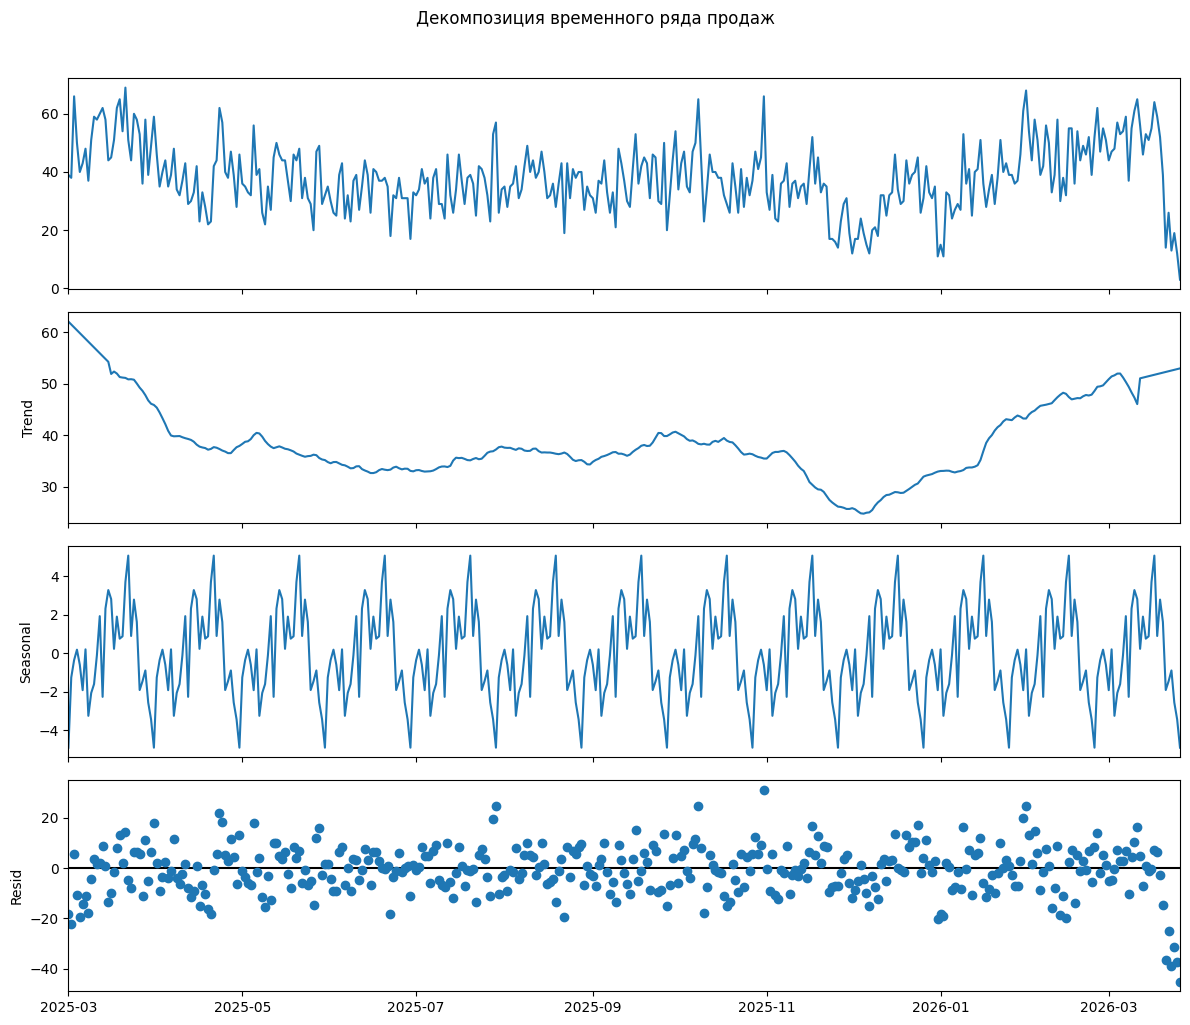

In [49]:
# Подготовка временного ряда
df_ts = my_full_copy[my_full_copy['buyout_flag'] == 1].copy()

# Преобразуем sale_ts в дату
df_ts['sale_date'] = pd.to_datetime(df_ts['sale_ts'], unit='s')

# Количество заказов в день
daily_orders = df_ts.groupby(df_ts['sale_date'].dt.date).size()
daily_orders.index = pd.to_datetime(daily_orders.index)
ts = daily_orders

# Выполняем декомпозицию
decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=30,
    extrapolate_trend='freq'
)

# Визуализация
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.suptitle("Декомпозиция временного ряда продаж", y=1.02)
plt.tight_layout()
plt.show()

Ряд имеет выраженную месячную сезонность. Выделим отдельные компоненты по дням (средние значения), чтобы детальнее разобраться в том, что происходит.

In [50]:
# Компоненты
components = pd.DataFrame({
    'date': ts.index,
    'observed': decomposition.observed,
    'trend': decomposition.trend,
    'seasonal': decomposition.seasonal,
    'resid': decomposition.resid
})

# Добавляем вспомогательные колонки
components['day_of_month'] = components['date'].dt.day
components['month'] = components['date'].dt.month
components['year_month'] = components['date'].dt.to_period('M')

print('-' * 50)
print("Средняя сезонность по дням месяца")
print("-" * 50)

seasonal_by_day = components.groupby('day_of_month')['seasonal'].mean().reset_index()
seasonal_by_day = seasonal_by_day.sort_values('day_of_month')
print(seasonal_by_day.to_string(index=False))

--------------------------------------------------
Средняя сезонность по дням месяца
--------------------------------------------------
 day_of_month  seasonal
            1 -1.381411
            2 -0.826875
            3 -1.240416
            4 -1.465691
            5 -1.107535
            6 -1.071766
            7 -0.492308
            8 -0.617584
            9  0.383383
           10  1.332320
           11  1.437421
           12  1.099826
           13  1.504971
           14  1.954422
           15  1.861935
           16  2.051647
           17  2.518586
           18  2.010168
           19  1.912500
           20  2.031202
           21  1.045466
           22  0.186259
           23 -0.290996
           24 -1.312453
           25 -2.123359
           26 -2.491044
           27 -2.025524
           28 -1.786587
           29 -1.949867
           30 -1.715731
           31 -1.236289


Временной ряд демонстрирует устойчивый внутримесячный сезонный паттерн с периодом 30 дней. Выделяются три характерные зоны:

- Зона спада (1–7 дни) — сезонный фактор снижает продажи на 1.1–2.8 ед. относительно тренда;
- Зона роста (8–20 дни) — сезонный фактор повышает продажи, достигая максимума +5.1 ед. 16-го числа;
- Зона спада (23–31 дни) — наиболее глубокое падение до -4.1 ед. 25-го числа.

Признак не содержит пропусков и является очень ценным для прогнозирования. На его основании можем получить производные признаки:

| Новый признак | Тип | Описание |
|---------------|-----|----------|
| `sale_hour` | числовой | Час продажи (0-23) |
| `sale_dayofweek` | числовой | День недели (0=пн, 6=вс) |
| `sale_month` | числовой | Месяц (1-12) |

In [51]:
def _add_sale_ts_features(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
    """
    Преобразует sale_ts в полезные признаки
    """

    # Преобразуем в datetime
    sale_ts = pd.to_datetime(block_df["sale_ts"], errors="coerce", unit='s')

    # Извлекаем компоненты
    result["sale_hour"] = sale_ts.dt.hour.astype(int)
    result["sale_dayofweek"] = sale_ts.dt.dayofweek.astype(int)
    result["sale_month"] = sale_ts.dt.month.astype(int)
    result["sale_ts"] = pd.to_datetime(block_df["sale_ts"], unit='s')

    print(f"Созданы признаки из sale_ts:")
    print(f"- sale_hour, sale_dayofweek, sale_month")
    print('-' * 50)

### lead_updated_at

In [52]:
# Преобразуем в даты
sale_date = pd.to_datetime(my_full_copy['sale_ts'], unit='s', errors='coerce')
updated_date = pd.to_datetime(my_full_copy['lead_updated_at'], unit='s', errors='coerce')

# Проверяем, когда updated_at позже sale_ts
updated_after_sale = (updated_date > sale_date).sum()
print(f"lead_updated_at позже sale_ts: {updated_after_sale} из {len(my_full_copy)}")

lead_updated_at позже sale_ts: 18886 из 18887


`lead_updated_at` всегда позже `sale_ts` — значит, это информация о будущем после заказа. Высокий риск утечки.
Исключаем.

In [53]:
cols_to_drop.append('lead_updated_at')

### contact_id

Данный признак является технической характеристикой пользователей и не будет полезными для прогнозирования выкупа.
Можно удалить.

In [54]:
cols_to_drop.append('contact_id')

### lead_условный отказ

In [55]:
block_df['lead_Условный отказ'].value_counts()

lead_Условный отказ
Посылка вернулась                        2479
Закажу позже                               76
Не интересует                              70
Дорого                                     66
Подумаю и закажу                           57
Тотальный не дозвон                        24
Не дозвонились                             21
Дубль                                      14
Консультация по стоимости                  12
Работа в др. сделке                        10
Уже заказал                                 9
Консультация по применению                  6
Ошиблись номером                            6
Консультация купившего                      4
Сброс                                       3
тест                                        1
Консультация Оформляет заказ на сайте       1
Доставка в др. Страну                       1
Разговора не было                           1
Name: count, dtype: int64

Причина отказа становится известна только после того, как клиент отказался от выкупа. Данный признак является утечкой.

In [56]:
cols_to_drop.append('lead_Условный отказ')

## Функции обработки признаков

In [57]:
def _add_default_feature(block_df: pd.DataFrame, result: pd.DataFrame, column: str) -> None:
    series = block_df[column]
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        result[column] = series.fillna("").astype(str)
    else:
        result[column] = series

## Итоговый датафрейм

In [58]:
X_block = pd.DataFrame(index=block_df.index)

for column in block_df.columns:
    if column in cols_to_drop:
        continue
    elif column == 'lead_Длина':
        _add_length_feature(block_df, X_block)
    elif column == 'lead_created_at':
        _add_timedelta_features(block_df, X_block)
    elif column == 'lead_Стоимость доставки':
        _add_shipping_cost(block_df, X_block)
    elif column == 'contact_Число сделок':
        _add_customer_loyalty_feature(block_df, X_block)
    elif column == 'lead_Скидка':
        _add_discount_feature(block_df, X_block)
    elif column == 'lead_Линейная ширина (см)' :
        _add_width_feature(block_df, X_block)
    elif column == 'lead_Источник':
        _add_lead_source_feature(block_df, X_block)
    elif column == 'sale_ts':
        _add_sale_ts_features(block_df, X_block)
    elif column == 'lead_Состав заказа':
        _add_order_composition_features(block_df, X_block)
    else:
        _add_default_feature(block_df, X_block, column)

print(f"Исключены признаки: {cols_to_drop}")
print('-' * 50)

print("Processed shape:", X_block.shape)
display(X_block.head())

Создан категориальный признак customer_loyalty
Распределение:
contact_loyalty
new        10250
unknown     4926
regular     3166
loyal        413
vip          132
Name: count, dtype: int64
Созданы признаки из lead_Состав заказа
Категории товаров:
  has_health_supplement: 195 (1.0%)
  has_pillow: 7067 (37.4%)
  has_mattress: 611 (3.2%)
  has_brace: 14374 (76.1%)
  has_footwear: 4074 (21.6%)
  has_accessory: 9727 (51.5%)
  has_health_product: 317 (1.7%)
--------------------------------------------------
Количество:
items_count (среднее): 3.23
total_quantity (среднее): 18.49
total_cost (среднее): 9775.63
--------------------------------------------------
Создан признак has_width
Заказов с шириной: 3128 (16.6%)
Выкупаемость с шириной: 77.3%
Выкупаемость без ширины: 82.1%
Разница: -4.7 п.п. (признак важен)
В оригинальном признаке пропуски заполнены -1
--------------------------------------------------

Создан категориальный признак discount_size
Распределение:
lead_discount_category
unknown

,row_id,contact_loyalty,lead_items_count,lead_total_quantity,lead_total_cost_from_composition,lead_has_health_supplement,lead_has_pillow,lead_has_mattress,lead_has_brace,lead_has_footwear,...,lead_created_ts,lead_created_dayofweek,lead_created_hour,lead_created_month,lead_has_shipping_cost,lead_shipping_cost,lead_has_length,lead_length,lead_price,lead_pipeline_id
0,0,new,2,521,2400,0,0,0,0,0,...,2025-03-01 03:40:54,5,3,3,0,-1.0,0,-1.0,2920,6892026
1,1,regular,2,301,2400,0,0,0,0,0,...,2025-03-01 05:30:30,5,5,3,0,-1.0,0,-1.0,2700,6892026
2,2,new,2,3,7800,0,0,0,1,0,...,2025-03-01 05:25:30,5,5,3,0,-1.0,0,-1.0,13200,6892026
3,3,regular,2,2,6000,0,0,0,1,0,...,2025-03-01 06:10:59,5,6,3,0,-1.0,0,-1.0,4800,6892026
4,4,new,2,3,11100,0,0,0,0,1,...,2025-03-01 06:01:18,5,6,3,0,-1.0,0,-1.0,12825,6892026


In [59]:
X_block.info()

<class 'pandas.DataFrame'>
RangeIndex: 18887 entries, 0 to 18886
Data columns (total 33 columns):
 #   Column                               Non-Null Count  Dtype        
---  ------                               --------------  -----        
 0   row_id                               18887 non-null  int64        
 1   contact_loyalty                      18887 non-null  str          
 2   lead_items_count                     18887 non-null  int64        
 3   lead_total_quantity                  18887 non-null  int64        
 4   lead_total_cost_from_composition     18887 non-null  int64        
 5   lead_has_health_supplement           18887 non-null  int64        
 6   lead_has_pillow                      18887 non-null  int64        
 7   lead_has_mattress                    18887 non-null  int64        
 8   lead_has_brace                       18887 non-null  int64        
 9   lead_has_footwear                    18887 non-null  int64        
 10  lead_has_accessory               

interval columns not set, guessing: ['row_id', 'lead_items_count', 'lead_total_quantity', 'lead_total_cost_from_composition', 'lead_has_health_supplement', 'lead_has_pillow', 'lead_has_mattress', 'lead_has_brace', 'lead_has_footwear', 'lead_has_accessory', 'lead_has_health_product', 'lead_categories_count', 'lead_has_linear_width', 'lead_linear_width', 'lead_discount', 'sale_hour', 'sale_dayofweek', 'sale_month', 'timedelta_between_sale_and_creation', 'lead_created_dayofweek', 'lead_created_hour', 'lead_created_month', 'lead_has_shipping_cost', 'lead_shipping_cost', 'lead_has_length', 'lead_length', 'lead_price', 'lead_pipeline_id']


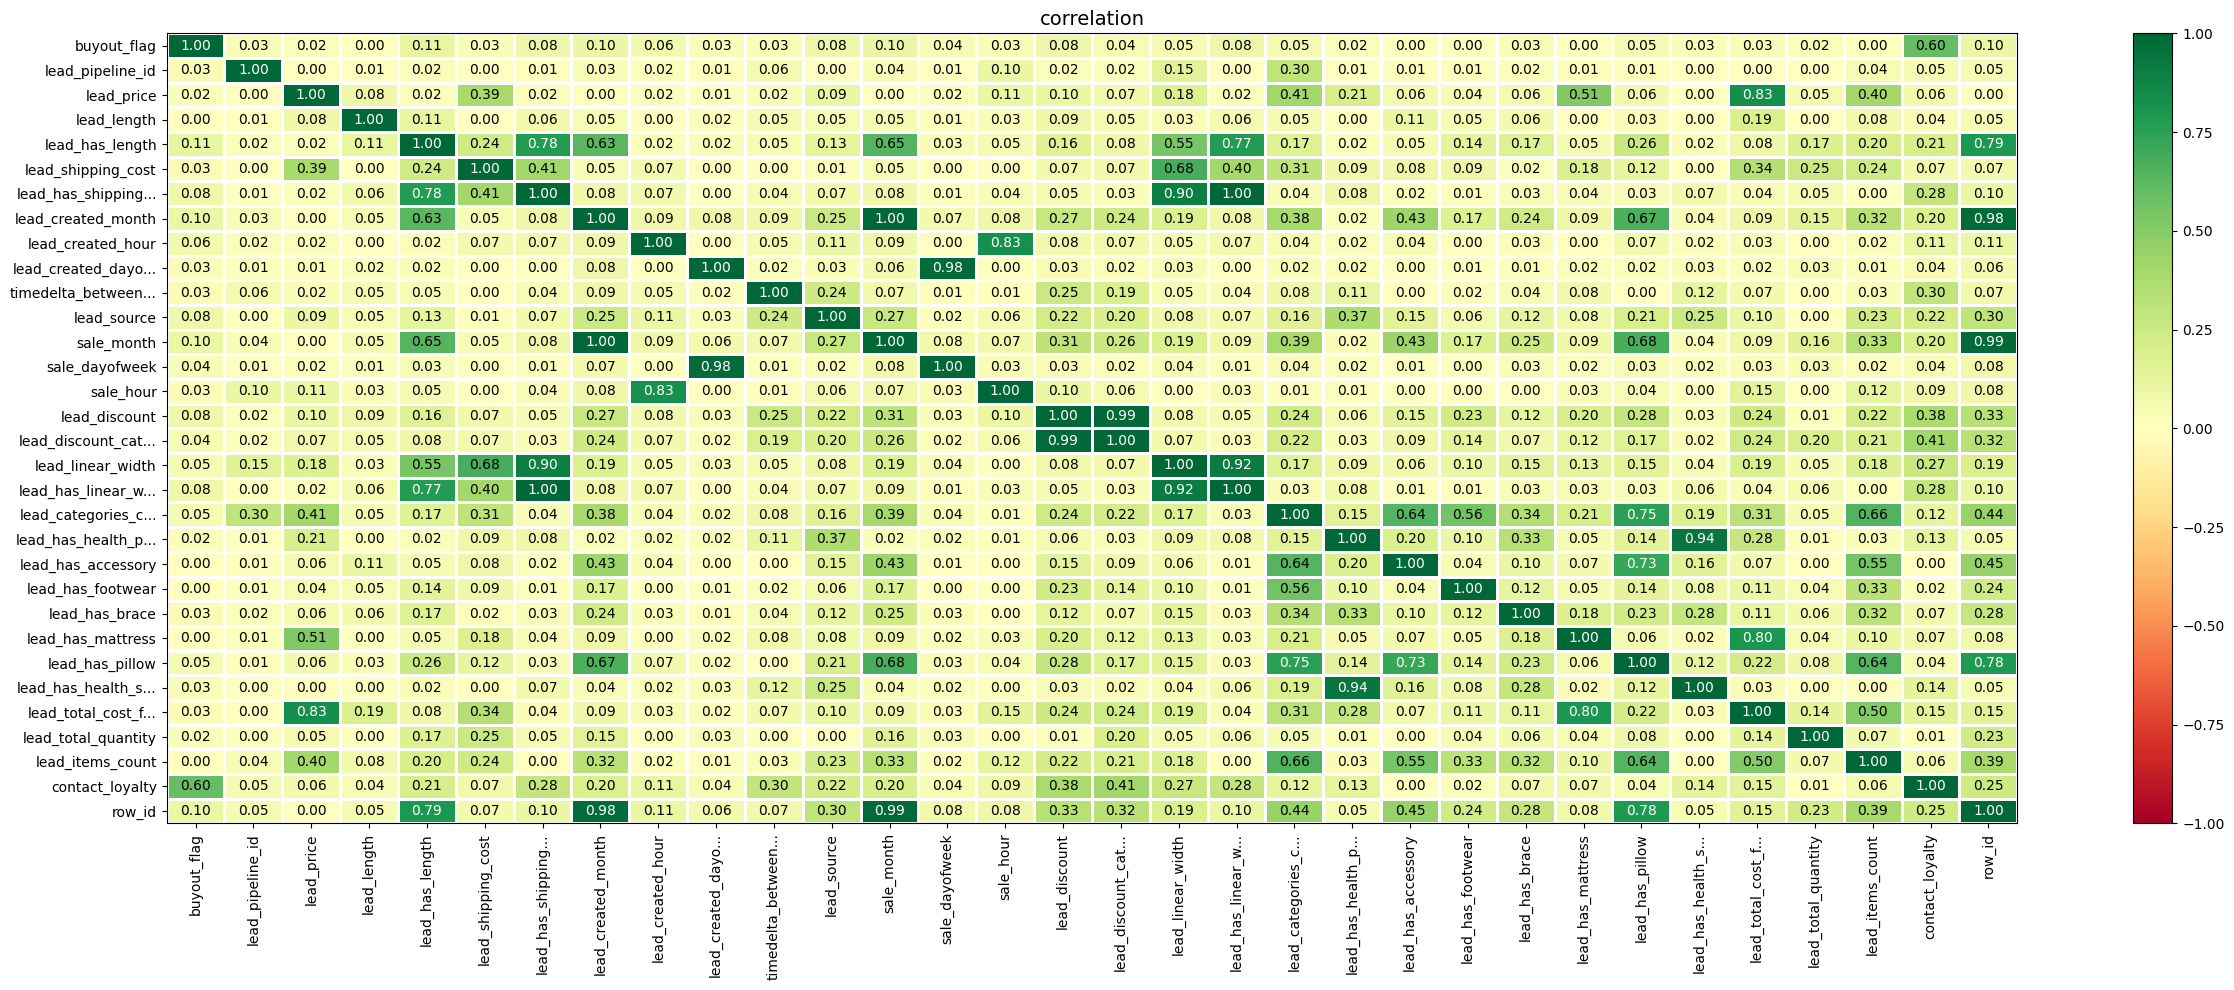

In [60]:
# Проверяем мультиколлинеарность
df_for_phik = X_block.copy()

df_for_phik['buyout_flag'] = my_full_copy['buyout_flag'].values

corr_matrix = phik_matrix(df_for_phik.drop(columns=[
    'sale_ts',
    'lead_created_ts'
]))

plot_correlation_matrix(corr_matrix.values,
                        x_labels=corr_matrix.columns,
                        y_labels=corr_matrix.index,
                        figsize=(25, 10))

In [61]:
X_block.to_csv(OUTPUT_DIR / "X_block.csv", index=False)
# feature_spec = create_feature_spec_template(X_block)
# feature_spec.to_csv(OUTPUT_DIR / "feature_spec.csv", index=False)

print("Saved:")
print(OUTPUT_DIR / "X_block.csv")
# print(OUTPUT_DIR / "feature_spec.csv")

Saved:
../../notebook_outputs/group_4/X_block.csv
